In [ ]:
# --- STEP 1: INPUT PARAMETERS ---
# Bottom-Up Company Monte Carlo Simulation
# Primary vs. Secondary PE Fund Comparison
# Quarterly NAV process based on Brown, Ghysels & Gredil (2023)


import numpy as np
import pandas as pd


# 1. SIMULATION SCALE & TIME GRID

N_SIMULATIONS = 10000       # Monte Carlo iterations
RANDOM_SEED   = 42           # For reproducibility

PERIODS_PER_YEAR    = 4
fund_lifetime_years = 10
fund_lifetime_q     = fund_lifetime_years * PERIODS_PER_YEAR  # 40 quarters
investment_period_y = 5
investment_period_q = investment_period_y * PERIODS_PER_YEAR  # 20 quarters


# 2. GENERAL MARKET ASSUMPTIONS (Quarterly)

market_return_q_mean = 0.0194  # ~1.94% expected quarterly return (8% annualized)
market_vol_q         = 0.0750  # 7.5% quarterly volatility (15% annualized)


# 3. FUND ARCHITECTURE

fund_size = 1.0  # Normalized committed capital


# 4. PRIMARY FUND — COMPANY-LEVEL ASSUMPTIONS

mean_n_companies = 12        # Mean number of portfolio companies
sd_n_companies   = 4         # Std dev of portfolio size
min_n_companies  = 5         # Hard floor

# A. Deployment Timing (Front-loaded over 20 quarters)
# Simplified mapping representing: Y1: 25%, Y2: 30%, Y3: 25%, Y4: 15%, Y5: 5%
primary_deploy_weights_q = {}
for q in range(1, 21):
    if q <= 4:   weight = 0.25 / 4
    elif q <= 8: weight = 0.30 / 4
    elif q <= 12: weight = 0.25 / 4
    elif q <= 16: weight = 0.15 / 4
    else:         weight = 0.05 / 4
    primary_deploy_weights_q[q] = weight

# B. Holding Period (Exit Timing)
mean_holding_period_q = 20.0 # Mean 5 years
sd_holding_period_q   = 6.0  # Std dev 1.5 years
min_holding_period_q  = 8.0  # Hard floor: 2 years (no flip sales)


# 5. SECTOR ALLOCATIONS & PARAMETERS (Quarterly Converted)
# Calibrated for realistic downside risk and upside potential across sectors

sector_weights = {
    'Technology': 0.25, 'Healthcare': 0.20, 'Consumer Discretionary': 0.18,
    'Industrials': 0.15, 'Financial Services': 0.10, 'Energy & Utilities': 0.07,
    'Real Estate': 0.05
}

sector_params = {
    'Technology':             
        {'g_TAM_q': 0.020, 'alpha_q': 0.025, 'sigma_idio_q': 0.300, 'mu_share': 0.02, 'sd_share': 0.01, 'ceiling_share': 0.15},
        # High growth, extreme volatility (freq. bankruptcies, high unicorns)
        
    'Healthcare':             
        {'g_TAM_q': 0.015, 'alpha_q': 0.020, 'sigma_idio_q': 0.250, 'mu_share': 0.03, 'sd_share': 0.01, 'ceiling_share': 0.20},
        # Biotech/Pharma risk makes this the second most volatile
        
    'Consumer Discretionary': 
        {'g_TAM_q': 0.010, 'alpha_q': 0.015, 'sigma_idio_q': 0.220, 'mu_share': 0.04, 'sd_share': 0.02, 'ceiling_share': 0.25},
        # Cyclical risk, highly sensitive to economic downturns
        
    'Financial Services':     
        {'g_TAM_q': 0.012, 'alpha_q': 0.012, 'sigma_idio_q': 0.200, 'mu_share': 0.03, 'sd_share': 0.015, 'ceiling_share': 0.20},
        # Leverage increases downside risk
        
    'Industrials':            
        {'g_TAM_q': 0.008, 'alpha_q': 0.010, 'sigma_idio_q': 0.150, 'mu_share': 0.05, 'sd_share': 0.02, 'ceiling_share': 0.30},
        # Capital intensive, but tangible assets provide a floor
        
    'Energy & Utilities':         
        {'g_TAM_q': 0.007, 'alpha_q': 0.008, 'sigma_idio_q': 0.120, 'mu_share': 0.06, 'sd_share': 0.02, 'ceiling_share': 0.35},
        # Regulated cash flows, highly stable
        
    'Real Estate':       
        {'g_TAM_q': 0.006, 'alpha_q': 0.005, 'sigma_idio_q': 0.100, 'mu_share': 0.05, 'sd_share': 0.015, 'ceiling_share': 0.30},
        # Most defensive sector. Lowest growth, lowest volatility.
}


# 6. SECONDARY FUND: TRANSACTION PARAMETERS

# A. Entry Timing
sec_entry_mean_q = 20.0  # Mean Quarter 20 (Year 5)
sec_entry_sd_q   = 4.0   # Std dev of 4 quarters
sec_entry_min_q  = 16.0  # Hard floor: Quarter 16 (Year 4)
sec_entry_max_q  = 36.0  # Hard ceiling: Quarter 36 (Year 9)

# B. NAV Discount
sec_discount_mean = 0.15  # 15% mean discount
sec_discount_sd   = 0.025 # 2.5% standard deviation
sec_discount_min  = 0.10  # Hard floor: 10% minimum discount
sec_discount_max  = 0.20  # Hard ceiling: 20% maximum discount


# 7. NAV REPORTING & SMOOTHING (Brown et al. 2023)

lambda_q    = 0.50  # GP appraisal smoothing weight (Quarterly approx of BGG 0.951 weekly)
sigma_noise = 0.05  # Random NAV reporting noise std dev

# VALIDATION DASHBOARD

assert abs(sum(primary_deploy_weights_q.values()) - 1.0) < 1e-9, "Deployment weights must sum to 1"
assert abs(sum(sector_weights.values()) - 1.0) < 1e-9, "Sector weights must sum to 1"
assert min_n_companies >= 1
assert sec_entry_min_q < sec_entry_max_q
assert sec_discount_min < sec_discount_max
assert 0 < lambda_q < 1


print(" STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated")

print(f"  Simulations:           {N_SIMULATIONS:,}")
print(f"  Time grid:             {fund_lifetime_q} quarters ({fund_lifetime_years} years)")
print(f"  Secondary entry:       Probabilistic (Bounds: Q{int(sec_entry_min_q)} to Q{int(sec_entry_max_q)})")
print(f"  Secondary discount:    Probabilistic (Bounds: {sec_discount_min:.0%} to {sec_discount_max:.0%})")


 STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated
  Simulations:           10,000
  Time grid:             40 quarters (10 years)
  Secondary entry:       Probabilistic (Bounds: Q16 to Q36)
  Secondary discount:    Probabilistic (Bounds: 10% to 20%)


In [ ]:
# --- STEP 2: BOTTOM-UP CASH FLOW & NAV ENGINE ---
# Generates N_SIMULATIONS funds: company-level GBM paths,
# fund-level cash flows + true NAV, BGG (2023) appraisal
# smoothing on cumulative log-returns, and the secondary
# buyer's CF stream.


import time
import numpy as np

print("Step 2: Bottom-Up Simulation Engine")
t0 = time.time()


# A. STORAGE ARRAYS (rows = each fund simulation, columns = quarters 0..40)

prim_calls_arr    = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # stored NEGATIVE
prim_dists_arr    = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # stored POSITIVE
true_nav_arr      = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # underlying value
rep_nav_arr       = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # BGG-smoothed NAV

# Internal AR state of the smoothed (for diagnostics & robustness)
r_true_period_arr = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # CF-adjusted true return
r_bar_period_arr  = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # smoothed periodic return

# Secondary buyer
sec_cf_arr        = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # buyer's net CFs
sec_metadata      = np.zeros((N_SIMULATIONS, 2))                    # [entry_q, discount]


# B. PRE-COMPUTE LOOKUPS (so np.random.choice is way faster if we compute everything in arrays)

sector_names = list(sector_weights.keys())
sector_probs = np.array(list(sector_weights.values()))
deploy_qs    = np.array(list(primary_deploy_weights_q.keys()))
deploy_probs = np.array(list(primary_deploy_weights_q.values()))

# Modern numpy Generator 
rng = np.random.default_rng(RANDOM_SEED) # re-running, the cell produces the exact same 10000 funds every time



# C. MAIN MONTE CARLO LOOP

for sim in range(N_SIMULATIONS):

    if (sim + 1) % 2000 == 0:
        print(f"  ... {sim + 1:,} / {N_SIMULATIONS:,}")

    # 1) Fund-level setup
    n_companies = int(max(min_n_companies,
                          np.round(rng.normal(mean_n_companies, sd_n_companies))))
    capital_per_company = fund_size / n_companies

    fund_true_nav = np.zeros(fund_lifetime_q + 1)

    # 2) Building of each company's value path and book it
    for c in range(n_companies):

        # Sector and growth parameters
        sector = rng.choice(sector_names, p=sector_probs)
        params = sector_params[sector]

        # Pick the investment quarter (drawn from staged deployment curve)
        invest_q = int(rng.choice(deploy_qs, p=deploy_probs))

        # Holding period: drawn, clipped to floor, capped at fund liquidation (at the end the fund liquidate everything)
        hold_q = int(max(min_holding_period_q,
                         np.round(rng.normal(mean_holding_period_q,
                                             sd_holding_period_q))))
        exit_q  = int(min(fund_lifetime_q, invest_q + hold_q)) # exit_q = investment quarter plus holding period
        periods = exit_q - invest_q # how many quarters a company is held

        if periods <= 0:
            continue   # if no holding time: skip (avoids leaking a capital call)

        # Sector-driven quarterly drift via market-share saturation
        mkt_share   = np.clip(rng.normal(params['mu_share'], params['sd_share']),  # the company's market share around the sector typical-level is drawn
                              0.001, params['ceiling_share'])                      # np.clip(calue, low, high) forces to stay within bounds
        penetration = mkt_share / params['ceiling_share']             # how saturated a company is
        drift       = params['g_TAM_q'] + params['alpha_q'] * (1 - penetration)   # EXPECTED GROWTH (quarterly) of a company
        sigma       = params['sigma_idio_q']   # Volatility 

        # GBM (Geometric Brownian Motion: array's simulation) company value path (log-normal). The k-th element is the value
        # at quarter invest_q + k (periods) + 1 (because at the time when company is bought its value is the same), for edxample the last value of the array is the value at exit_q (invest_q + periods).
        shocks      = rng.normal(0, sigma, periods)  # based on the sector
        log_returns = drift - 0.5 * sigma**2 + shocks # Stochastic calculus: Volatility drag correction with 0.5 * sigma^2 (CFR. Lemma di Ito!!!)
        values      = capital_per_company * np.exp(np.cumsum(log_returns)) # cumulativ sum and exp because of Limited Liability (drawn quarter by quarter)

        # Cash Flows Bookkeeping (symmetric at investment and exit)
        prim_calls_arr[sim, invest_q] -= capital_per_company       # cash call (outflow: it substracts the value from this column)
        fund_true_nav[invest_q]       += capital_per_company       # asset on books at face value (exactly at the price bought in that quarter) 
        if periods > 1:                                           # if periods = 1 we skip it
            fund_true_nav[invest_q + 1 : exit_q] += values[:-1]    # holding-period NAV ( summing up all the values - not the last one - to get the total quarterly NAV)
        prim_dists_arr[sim, exit_q]   += values[-1]                # exit value distributed (last value of the list)
        # fund_true_nav[exit_q] does NOT include this company: it has been sold so not considered

    true_nav_arr[sim] = fund_true_nav # Quarterly NAV is built ending the loop for companies (obviously a row with 41 columns)

    # 3) BGG (2023) appraisal smoothing on cumulative log-returns
    # State equation (cumulative form, r_bar is what has been declared, r is the real return from beginning to today)
    #     r_bar_{0:t} = (1 - lambda)*r_{0:t} + lambda*r_bar_{0:t-1}
    # Fund Reported NAV (in values, for example in USD or EUR):
    #     log NAV_rep_t = log V_t + (r_bar_{0:t} - r_{0:t}) + n_t,   n_t is N(0, sigma_n^2) - "Random reporting noise" considering the stddev on the NAV reporting noise, V_t = true value
    fund_rep_nav = np.zeros(fund_lifetime_q + 1)
    r_cum     = 0.0    # TRUE cumulative log-return (r_cum and r_bar_cum start at zero and we update them each quarter)
    r_bar_cum = 0.0    # smoothed cumulative log-return (followinf r_cum but iin delay because of the smoothing factor)

    for t in range(1, fund_lifetime_q + 1): # t is the current quarter
        denom = fund_true_nav[t - 1] # last quarter's NAV (V_{t-1})
        # CF-adjusted period log-return: (V_t + D_t - C_paid_t) / V_{t-1} 
        # Calls stored as negative (so +) # from true Asset Value formula in BGG paper
        numer = fund_true_nav[t] + prim_dists_arr[sim, t] + prim_calls_arr[sim, t]  # this quarter's NAV + this quarter's dist + this quarter's calls

        if denom > 1e-9 and numer > 1e-9:
            r_t = np.log(numer / denom) # quarterly return
        else:
            r_t = 0.0   # fund not active this quarter

        r_cum_new     = r_cum + r_t
        r_bar_cum_new = lambda_q * r_bar_cum + (1 - lambda_q) * r_cum_new # psychology into account (Appraisal Smoothing from BGG): GPs ANCHORING

        # Periodic returns 
        r_true_period_arr[sim, t] = r_t
        r_bar_period_arr[sim, t]  = r_bar_cum_new - r_bar_cum # to verify autocorrelation that mathces BGG's empirical value

        if fund_true_nav[t] > 1e-9:
            noise = rng.normal(0, sigma_noise)
            fund_rep_nav[t] = fund_true_nav[t] * np.exp((r_bar_cum_new - r_cum_new) + noise) # from BGG, after smoothing there is the conversion in value (for ex. USD or EUR)
        else:
            fund_rep_nav[t] = 0.0

        r_cum     = r_cum_new
        r_bar_cum = r_bar_cum_new

    rep_nav_arr[sim] = fund_rep_nav # after the quarter loop, copy this fund's colpeted reported-NAV path into its row of the big grid

    # 4) Secondary buyer's CF stream
    entry_q = int(np.round(np.clip(
                    rng.normal(sec_entry_mean_q, sec_entry_sd_q),
                    sec_entry_min_q, sec_entry_max_q)))
    discount = float(np.clip(
                    rng.normal(sec_discount_mean, sec_discount_sd),
                    sec_discount_min, sec_discount_max))

    sec_metadata[sim, 0] = entry_q # clumn 0 = entry quarter 
    sec_metadata[sim, 1] = discount # column 1 = discount

    # Buyer pays (1 - d) * REPORTED NAV at entry
    purchase_price = fund_rep_nav[entry_q] * (1 - discount) # on the reported NAV 
    sec_cf_arr[sim, entry_q] -= purchase_price # substracted in the secondary CF grid
    if entry_q < fund_lifetime_q: # now they acquire all the subsequent cash flows, so we copy into the buyer's CF row
        sec_cf_arr[sim, entry_q + 1:] += prim_calls_arr[sim, entry_q + 1:]
        sec_cf_arr[sim, entry_q + 1:] += prim_dists_arr[sim, entry_q + 1:]


# D. COMPLETION

elapsed = time.time() - t0
print("=" * 65)
print(" STEP 2 COMPLETE: DATA MATRICES GENERATED")
print("=" * 65)
print(f"  Total compute time:      {elapsed:.1f} seconds")
print(f"  Primary calls shape:     {prim_calls_arr.shape}")
print(f"  Primary dists shape:     {prim_dists_arr.shape}")
print(f"  True NAV shape:          {true_nav_arr.shape}")
print(f"  Reported NAV shape:      {rep_nav_arr.shape}")
print(f"  Secondary CF shape:      {sec_cf_arr.shape}")
print("=" * 65)


# E. VALIDATION DIAGNOSTICS


# i) BGG smoothing validation: autocorrelation of periodic log-returns
def autocorr1_panel(series, q_lo=4, q_hi=37): # we are looking only between the second and nineth year
    """Per-fund lag-1 autocorrelation, restricted to the mid-fund active window."""
    rho = []
    for s in range(series.shape[0]): # 10000
        r = series[s, q_lo:q_hi] 
        if r.std() > 1e-9 and len(r) > 4: # Company is active and at least 4 quarters
            x = r[:-1] - r[:-1].mean() # array of past returns (x Pearson correlation)
            y = r[1:]  - r[1:].mean() # array of today's returns (x Pearson correlation)
            denom = np.sqrt((x * x).sum() * (y * y).sum())  
            if denom > 0:
                rho.append((x * y).sum() / denom) # Pearson corrrelation
    return np.array(rho) # target: 0 for reality and around 0.41 for Smoothing Accountability (BGG)

rho_true = autocorr1_panel(r_true_period_arr)
rho_bar  = autocorr1_panel(r_bar_period_arr)

print(f"\n  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):")
print(f"    r_t (true, i.i.d. by construction):  rho_1 = {rho_true.mean():+.3f}   (target ~0)")
print(f"    r_bar_t (smoothed):                  rho_1 = {rho_bar.mean():+.3f}   (target ~ BGG empirical 0.41)")

# ii) Year-end averages: it should show classic primary-fund pattern
mean_true       = true_nav_arr.mean(axis=0)
mean_rep        = rep_nav_arr.mean(axis=0)
mean_cum_called = prim_calls_arr.cumsum(axis=1).mean(axis=0) # 1st axis = time; 0 axis = funds
mean_cum_dist   = prim_dists_arr.cumsum(axis=1).mean(axis=0)

print(f"\n  Year-end averages:")
print(f"  {'Y':>3} {'NAV_true':>10} {'NAV_rep':>10} {'Cum.Called':>12} {'Cum.Dist':>10}")
for y in [0, 1, 2, 3, 5, 7, 10]: # years
    q = y * 4 # quarter
    print(f"  {y:>3} {mean_true[q]:>10.4f} {mean_rep[q]:>10.4f} "
          f"{-mean_cum_called[q]:>12.4f} {mean_cum_dist[q]:>10.4f}")

# iii) Headline multiples
final_value  = prim_dists_arr.sum(axis=1) + true_nav_arr[:, -1] # we sum all the distributions and if there is still at the end of year 10 an unsold fund value, it is added here
final_called = -prim_calls_arr.sum(axis=1)
TVPI         = final_value / final_called

print(f"\n  Terminal TVPI: mean {TVPI.mean():.2f}x, median {np.median(TVPI):.2f}x, "
      f"P10 {np.percentile(TVPI, 10):.2f}x, P90 {np.percentile(TVPI, 90):.2f}x")

Step 2: Bottom-Up Simulation Engine
  ... 2,000 / 10,000
  ... 4,000 / 10,000
  ... 6,000 / 10,000
  ... 8,000 / 10,000
  ... 10,000 / 10,000
 STEP 2 COMPLETE: DATA MATRICES GENERATED
  Total compute time:      9.8 seconds
  Primary calls shape:     (10000, 41)
  Primary dists shape:     (10000, 41)
  True NAV shape:          (10000, 41)
  Reported NAV shape:      (10000, 41)
  Secondary CF shape:      (10000, 41)

  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):
    r_t (true, i.i.d. by construction):  rho_1 = -0.030   (target ~0)
    r_bar_t (smoothed):                  rho_1 = +0.419   (target ~0.50; BGG empirical 0.41)

  Year-end averages:
    Y   NAV_true    NAV_rep   Cum.Called   Cum.Dist
    0     0.0000     0.0000      -0.0000     0.0000
    1     0.2619     0.2574       0.2515     0.0000
    2     0.6072     0.5907       0.5518     0.0000
    3     0.9213     0.8954       0.8007     0.0158
    5     1.1577     1.1220       1.0000     0.2201
    7     0.

In [ ]:
# --- STEP 3: PERFORMANCE METRICS (IRR / TVPI / DPI) ---
# Per-fund metrics, averaged across funds (LP-experience IRR).
# Primary: by fund age.  Secondary: by buyer age AND calendar quarter.
# TVPI/IRR computed at both reported and true NAV marks.


import numpy as np

# --- Vectorized quarterly IRR via bisection (matches numpy_financial) ---
def irr_quarterly_vec(cf, lo=-0.9999, hi=10.0, n_iter=200):
    """cf: [n_funds, n_periods] quarterly cash flows. Returns quarterly IRR per fund."""
    cf = np.asarray(cf, dtype=float)
    powers = np.arange(cf.shape[1])
    lo_a = np.full(cf.shape[0], lo)
    hi_a = np.full(cf.shape[0], hi)
    def npv(rate):
        return (cf / (1.0 + rate[:, None]) ** powers[None, :]).sum(axis=1)
    bracketed = np.sign(npv(lo_a)) != np.sign(npv(hi_a))  # IRR exists only if NPV changes sign
    for _ in range(n_iter):
        mid = 0.5 * (lo_a + hi_a)
        pos = npv(mid) > 0                 # NPV is decreasing in the rate
        lo_a = np.where(pos, mid, lo_a)
        hi_a = np.where(pos, hi_a, mid)
    irr_q = 0.5 * (lo_a + hi_a)
    irr_q[~bracketed] = np.nan
    return irr_q

annualize = lambda irr_q: (1 + irr_q) ** 4 - 1
eps = 1e-12
Q = fund_lifetime_q


# A. PRIMARY FUND: trajectories by fund age

net_cf    = prim_calls_arr + prim_dists_arr
cum_calls = (-prim_calls_arr).cumsum(axis=1)     # cumulative paid-in (positive)
cum_dists = prim_dists_arr.cumsum(axis=1)        # cumulative distributions
called    = cum_calls > eps                      # mask: capital actually called by now

TVPI_prim_rep  = np.where(called, (cum_dists + rep_nav_arr)  / np.maximum(cum_calls, eps), np.nan)
TVPI_prim_true = np.where(called, (cum_dists + true_nav_arr) / np.maximum(cum_calls, eps), np.nan)
DPI_prim       = np.where(called,  cum_dists                  / np.maximum(cum_calls, eps), np.nan)

IRR_prim_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_prim_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    base = net_cf[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    IRR_prim_rep[:, t]  = annualize(irr_quarterly_vec(b_rep))
    IRR_prim_true[:, t] = annualize(irr_quarterly_vec(b_true))


# B. SECONDARY FUND — reconstruct buyer cash flows

entry_qs  = sec_metadata[:, 0].astype(int)
discounts = sec_metadata[:, 1]

# B1. Buyer-age alignment: shift each fund so entry_q -> index 0
max_age      = Q - int(sec_entry_min_q)
sec_cf_age   = np.zeros((N_SIMULATIONS, max_age + 1))
nav_rep_age  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
nav_true_age = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]; h = Q - eq
    sec_cf_age[sim, :h + 1]   = sec_cf_arr[sim, eq:Q + 1]
    nav_rep_age[sim, :h + 1]  = rep_nav_arr[sim, eq:Q + 1]
    nav_true_age[sim, :h + 1] = true_nav_arr[sim, eq:Q + 1]

cum_sec_dist_age = np.where(sec_cf_age > 0,  sec_cf_age, 0).cumsum(axis=1)
cum_sec_call_age = np.where(sec_cf_age < 0, -sec_cf_age, 0).cumsum(axis=1)  # includes purchase at k=0

IRR_sec_age_rep  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
IRR_sec_age_true = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_rep = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_true= np.full((N_SIMULATIONS, max_age + 1), np.nan)
DPI_sec_age      = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for k in range(1, max_age + 1):
    valid = ~np.isnan(nav_rep_age[:, k])
    base = sec_cf_age[:, :k + 1].copy()
    b_rep  = base.copy();  b_rep[:, k]  += np.nan_to_num(nav_rep_age[:, k])
    b_true = base.copy();  b_true[:, k] += np.nan_to_num(nav_true_age[:, k])
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_age_rep[valid, k]  = ir[valid]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_age_true[valid, k] = it[valid]
    paid = np.maximum(cum_sec_call_age[:, k], eps)
    TVPI_sec_age_rep[valid, k]  = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_rep_age[:, k]))  / paid)[valid]
    TVPI_sec_age_true[valid, k] = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_true_age[:, k])) / paid)[valid]
    DPI_sec_age[valid, k]       = (cum_sec_dist_age[:, k] / paid)[valid]

# B2. Calendar alignment: keep secondary CFs on the absolute Q0..Q40 grid
cum_sec_dist_cal = np.where(sec_cf_arr > 0,  sec_cf_arr, 0).cumsum(axis=1)
cum_sec_call_cal = np.where(sec_cf_arr < 0, -sec_cf_arr, 0).cumsum(axis=1)
IRR_sec_cal_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_sec_cal_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
TVPI_sec_cal_rep = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    active = entry_qs < t                       # only funds already entered
    base = sec_cf_arr[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_cal_rep[active, t]  = ir[active]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_cal_true[active, t] = it[active]
    paid = np.maximum(cum_sec_call_cal[:, t], eps)
    TVPI_sec_cal_rep[active, t] = ((cum_sec_dist_cal[:, t] + rep_nav_arr[:, t]) / paid)[active]


# C. AGGREGATE to mean / median / percentile trajectories

def summarize(panel):
    return {
        'mean':   np.nanmean(panel, axis=0),
        'median': np.nanmedian(panel, axis=0),
        'p25':    np.nanpercentile(panel, 25, axis=0),
        'p75':    np.nanpercentile(panel, 75, axis=0),
        'p10':    np.nanpercentile(panel, 10, axis=0),
        'p90':    np.nanpercentile(panel, 90, axis=0),
    }

metrics = {
    'primary': {
        'IRR_rep':  summarize(IRR_prim_rep),  'IRR_true':  summarize(IRR_prim_true),
        'TVPI_rep': summarize(TVPI_prim_rep), 'TVPI_true': summarize(TVPI_prim_true),
        'DPI':      summarize(DPI_prim),
    },
    'secondary_by_age': {
        'IRR_rep':  summarize(IRR_sec_age_rep),  'IRR_true':  summarize(IRR_sec_age_true),
        'TVPI_rep': summarize(TVPI_sec_age_rep), 'TVPI_true': summarize(TVPI_sec_age_true),
        'DPI':      summarize(DPI_sec_age),
        'n_funds':  (~np.isnan(IRR_sec_age_rep)).sum(axis=0),
    },
    'secondary_by_calendar': {
        'IRR_rep':  summarize(IRR_sec_cal_rep),  'IRR_true':  summarize(IRR_sec_cal_true),
        'TVPI_rep': summarize(TVPI_sec_cal_rep),
    },
}


# D. SUMMARY OUTPUT

print("=" * 65)
print(" STEP 3 COMPLETE: PERFORMANCE METRICS")
print("=" * 65)
print("\n  PRIMARY (per-fund mean, reported NAV mark), by fund age:")
print(f"  {'Yr':>3} {'IRR%':>7} {'TVPI':>6} {'DPI':>6}")
for y in [1, 2, 3, 4, 5, 6, 7, 8, 10]:
    q = y * 4
    print(f"  {y:>3} {metrics['primary']['IRR_rep']['mean'][q]*100:>7.1f} "
          f"{metrics['primary']['TVPI_rep']['mean'][q]:>6.2f} "
          f"{metrics['primary']['DPI']['mean'][q]:>6.2f}")

print("\n  SECONDARY (per-fund mean), by buyer age:")
print(f"  {'Qtr':>3} {'IRR%_rep':>9} {'IRR%_true':>10} {'TVPI_rep':>9} {'n':>6}")
for k in [1, 2, 4, 8, 12, 16, 20]:
    if k <= max_age:
        print(f"  {k:>3} {metrics['secondary_by_age']['IRR_rep']['mean'][k]*100:>9.1f} "
              f"{metrics['secondary_by_age']['IRR_true']['mean'][k]*100:>10.1f} "
              f"{metrics['secondary_by_age']['TVPI_rep']['mean'][k]:>9.2f} "
              f"{metrics['secondary_by_age']['n_funds'][k]:>6}")
print("=" * 65)

C:\Users\Gianni\AppData\Local\Temp\ipykernel_22040\3578587377.py:112: RuntimeWarning: Mean of empty slice
  'mean':   np.nanmean(panel, axis=0),
c:\Users\Gianni\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1216: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\Users\Gianni\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


 STEP 3 COMPLETE: PERFORMANCE METRICS

  PRIMARY (per-fund mean, reported NAV mark), by fund age:
   Yr    IRR%   TVPI    DPI
    1     9.6   1.02   0.00
    2     8.1   1.07   0.00
    3     8.7   1.14   0.02
    4     9.1   1.22   0.08
    5     9.5   1.34   0.22
    6     9.8   1.48   0.49
    7    10.0   1.59   0.83
    8    10.1   1.68   1.18
   10    10.1   1.77   1.77

  SECONDARY (per-fund mean), by buyer age:
  Qtr  IRR%_rep  IRR%_true  TVPI_rep      n
    1     127.5      168.8      1.21   9995
    2      60.2       71.3      1.24   9995
    4      35.7       39.3      1.30   9995
    8      25.4       26.5      1.42   9988
   12      22.0       22.4      1.51   9840
   16      20.3       20.5      1.58   8722
   20      18.5       18.6      1.67   5492


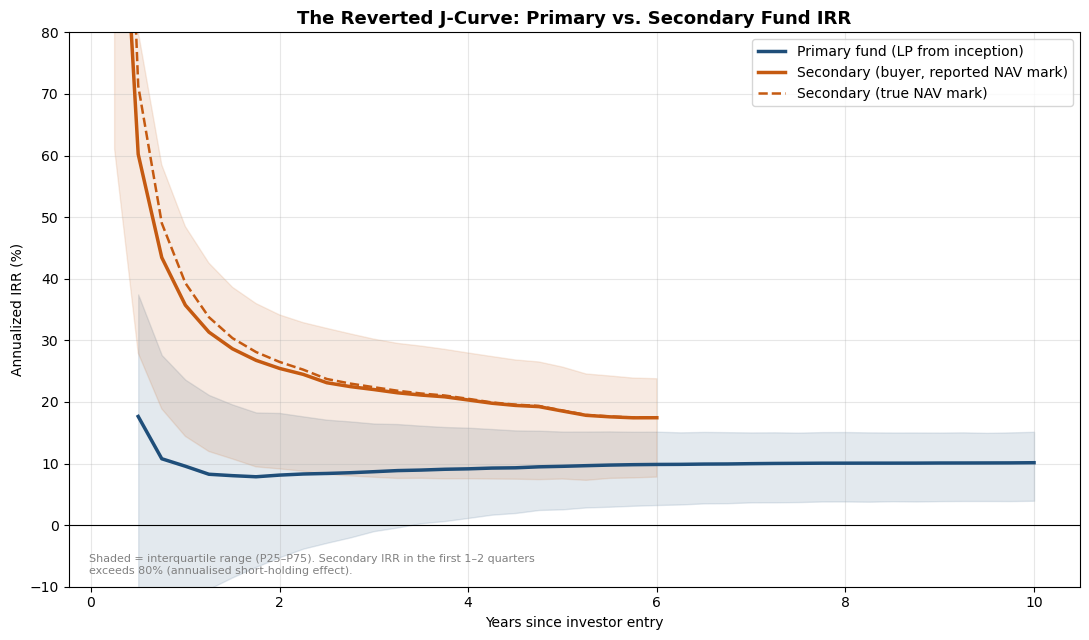

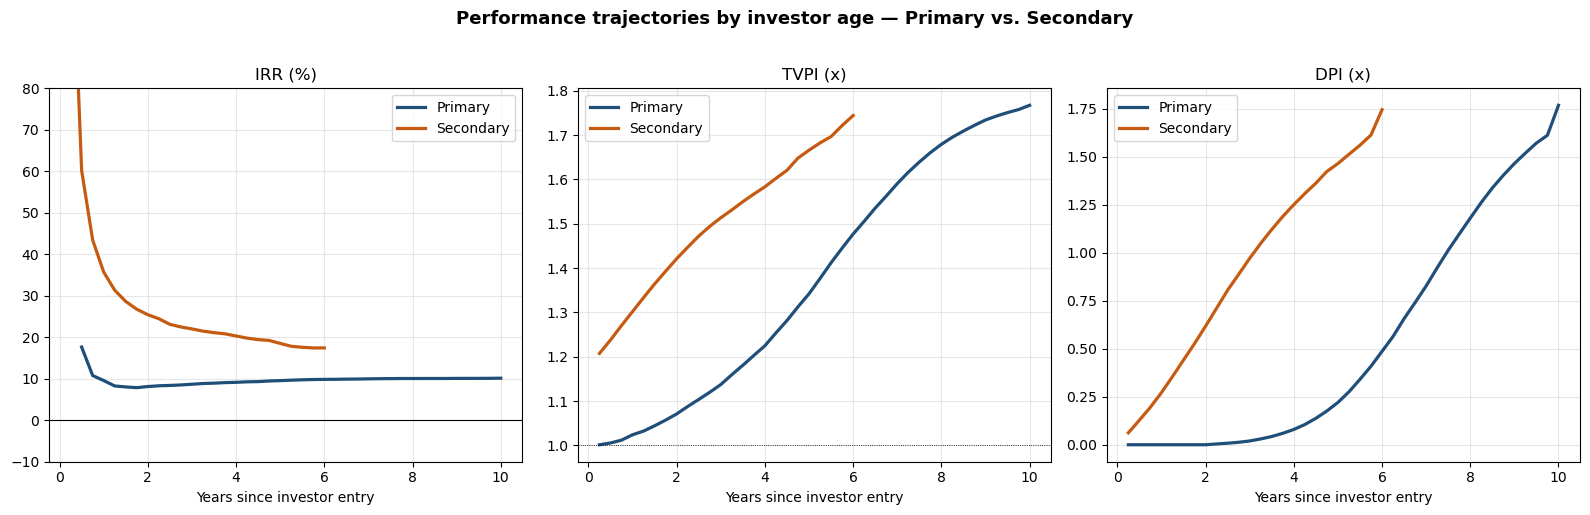

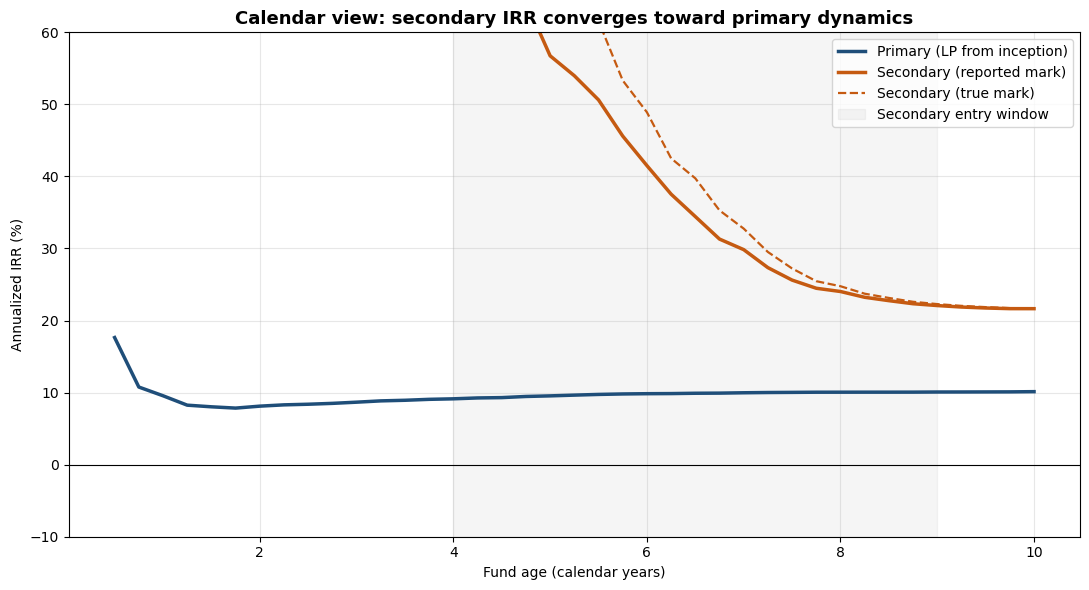

In [ ]:
# --- STEP 4: VISUALISING THE REVERTED J-CURVE ---
# Fig 1: headline reverted-J (investor-age aligned, both NAV marks, bands)
# Fig 2: IRR / TVPI / DPI three-panel (investor-age aligned)
# Fig 3: calendar-aligned convergence view


import numpy as np
import warnings
import matplotlib.pyplot as plt

C_PRIM = '#1f4e79'   # primary  = dark blue
C_SEC  = '#c55a11'   # secondary = burnt orange

# Sample-size truncation: only plot buyer-ages with >= 1000 funds
n_by_age = (~np.isnan(IRR_sec_age_rep)).sum(axis=0) # how many funds  
trunc = max(k for k in range(max_age + 1) if n_by_age[k] >= 1000)

# X-axes (in years)
yr_fund = np.arange(Q + 1) / 4            # primary fund age / calendar quarter
yr_age  = np.arange(max_age + 1) / 4      # secondary buyer age

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Primary (by fund age)
    pri_irr  = np.nanmean(IRR_prim_rep, 0)
    pri_irr_lo, pri_irr_hi = np.nanpercentile(IRR_prim_rep, [25, 75], 0)
    pri_tvpi = np.nanmean(TVPI_prim_rep, 0)
    pri_dpi  = np.nanmean(DPI_prim, 0)

    # Secondary by buyer age
    sec_irr_rep  = np.nanmean(IRR_sec_age_rep, 0)
    sec_irr_true = np.nanmean(IRR_sec_age_true, 0)
    sec_irr_lo, sec_irr_hi = np.nanpercentile(IRR_sec_age_rep, [25, 75], 0)
    sec_tvpi = np.nanmean(TVPI_sec_age_rep, 0)
    sec_dpi  = np.nanmean(DPI_sec_age, 0)

    # Secondary by calendar quarter
    n_cal      = (~np.isnan(IRR_sec_cal_rep)).sum(axis=0)
    sec_cal_rep  = np.nanmean(IRR_sec_cal_rep, 0)
    sec_cal_true = np.nanmean(IRR_sec_cal_true, 0)

kt = trunc + 1   # slice end for buyer-age series


# FIGURE 1: Headline reverted J-curve (investor-age aligned)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(yr_fund, pri_irr * 100, color=C_PRIM, lw=2.5,
        label='Primary fund (LP from inception)')
ax.fill_between(yr_fund, pri_irr_lo * 100, pri_irr_hi * 100, color=C_PRIM, alpha=0.12)
ax.plot(yr_age[:kt], sec_irr_rep[:kt] * 100, color=C_SEC, lw=2.5,
        label='Secondary (buyer, reported NAV mark)')
ax.plot(yr_age[:kt], sec_irr_true[:kt] * 100, color=C_SEC, lw=1.8, ls='--',
        label='Secondary (true NAV mark)')
ax.fill_between(yr_age[:kt], sec_irr_lo[:kt] * 100, sec_irr_hi[:kt] * 100,
                color=C_SEC, alpha=0.12)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Years since investor entry')
ax.set_ylabel('Annualized IRR (%)')
ax.set_title('The Reverted J-Curve: Primary vs. Secondary Fund IRR',
             fontweight='bold', fontsize=13)
ax.set_ylim(-10, 80)   # secondary IRR exceeds this in the first ~2 quarters
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.text(0.02, 0.02,
        'Shaded = interquartile range (P25–P75). Secondary IRR in the first 1–2 quarters\n'
        'exceeds 80% (annualised short-holding effect).',
        transform=ax.transAxes, fontsize=8, color='gray', va='bottom')
plt.tight_layout()
plt.show()


# FIGURE 2: IRR / TVPI / DPI three-panel (investor-age aligned)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(yr_fund, pri_irr * 100, color=C_PRIM, lw=2.3, label='Primary')
axes[0].plot(yr_age[:kt], sec_irr_rep[:kt] * 100, color=C_SEC, lw=2.3, label='Secondary')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('IRR (%)'); axes[0].set_ylim(-10, 80)

axes[1].plot(yr_fund, pri_tvpi, color=C_PRIM, lw=2.3, label='Primary')
axes[1].plot(yr_age[:kt], sec_tvpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[1].axhline(1, color='k', lw=0.6, ls=':')
axes[1].set_title('TVPI (x)')

axes[2].plot(yr_fund, pri_dpi, color=C_PRIM, lw=2.3, label='Primary')
axes[2].plot(yr_age[:kt], sec_dpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[2].set_title('DPI (x)')

for a in axes:
    a.set_xlabel('Years since investor entry')
    a.legend(); a.grid(alpha=0.3)
fig.suptitle('Performance trajectories by investor age — Primary vs. Secondary',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# FIGURE 3 — Calendar-aligned convergence view

fig, ax = plt.subplots(figsize=(11, 6))
m = n_cal >= 1000   # plot secondary only where >= 1000 funds have entered
ax.plot(yr_fund, pri_irr * 100, color=C_PRIM, lw=2.5,
        label='Primary (LP from inception)')
ax.plot(yr_fund[m], sec_cal_rep[m] * 100, color=C_SEC, lw=2.5,
        label='Secondary (reported mark)')
ax.plot(yr_fund[m], sec_cal_true[m] * 100, color=C_SEC, lw=1.6, ls='--',
        label='Secondary (true mark)')
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(sec_entry_min_q / 4, sec_entry_max_q / 4, color='gray', alpha=0.08,
           label='Secondary entry window')
ax.set_xlabel('Fund age (calendar years)')
ax.set_ylabel('Annualized IRR (%)')
ax.set_title('Calendar view: secondary IRR converges toward primary dynamics',
             fontweight='bold', fontsize=13)
ax.set_ylim(-10, 60)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Running the Implied Discount Estimator on all simulated funds...


C:\Users\Gianni\AppData\Local\Temp\ipykernel_22040\2842952336.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:,.0%}'.format(x) for x in vals_x])
C:\Users\Gianni\AppData\Local\Temp\ipykernel_22040\2842952336.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals_y])


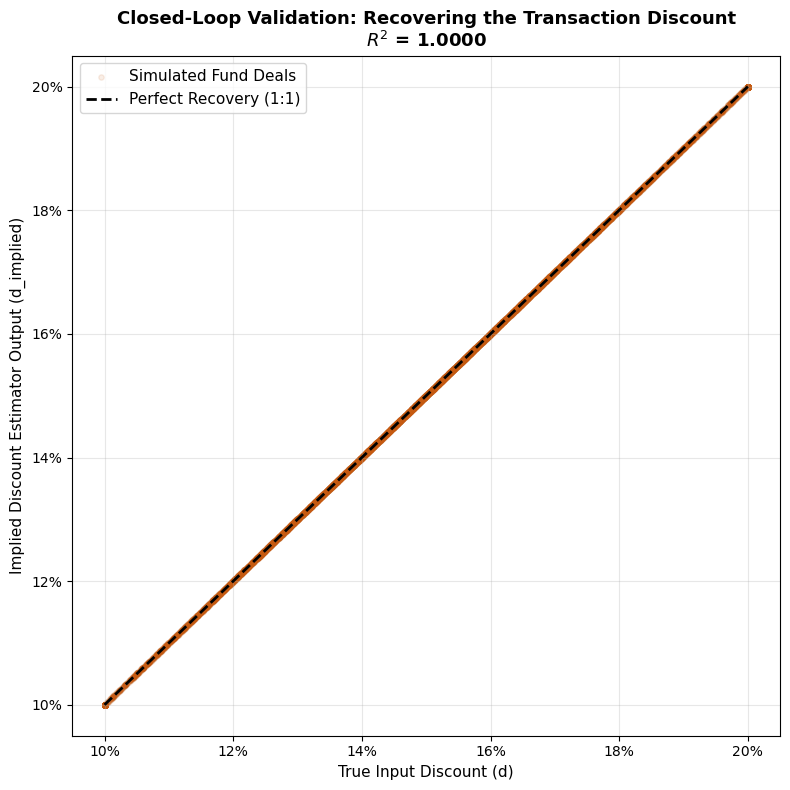

Closed-Loop Check Successful. Estimator Accuracy (R-squared): 100.00%


In [ ]:
# --- STEP 5_draft: THE IMPLIED DISCOUNT ESTIMATOR (Study I Finale) ---
# Validating the Closed-Loop Check: Recovering the true discount
# from the observed TVPI performance gap.


from scipy import stats

print("Running the Implied Discount Estimator on all simulated funds...")

implied_discounts = []
actual_discounts = []

for sim in range(N_SIMULATIONS):
    entry_q = int(sec_metadata[sim, 0])
    true_d  = sec_metadata[sim, 1]
    
    # 1. Gather observable data at the exact moment of the secondary transaction
    nav_t = rep_nav_arr[sim, entry_q]
    
    # Skip edge cases (e.g., fund already liquidated or NAV effectively zero)
    if nav_t < 1e-4:
        continue
        
    # Future cash flows from Q(entry+1) to final liquidation
    future_calls = abs(np.sum(prim_calls_arr[sim, entry_q + 1:]))
    future_dists = np.sum(prim_dists_arr[sim, entry_q + 1:])
    
    # Total future value includes distributions + final liquidating NAV
    total_future_value = future_dists + rep_nav_arr[sim, -1] 
    
    # 2. Calculate the observable TVPIs from Quarter T onwards
    # Primary TVPI cost basis = Future Calls + NAV_T (Opportunity cost)
    cost_basis_prim = future_calls + nav_t
    tvpi_prim = total_future_value / cost_basis_prim if cost_basis_prim > 0 else 0
    
    # Secondary TVPI cost basis = Future Calls + (NAV_T * (1 - Discount))
    cost_basis_sec = future_calls + (nav_t * (1 - true_d))
    tvpi_sec = total_future_value / cost_basis_sec if cost_basis_sec > 0 else 0
    
    # 3. Apply the Algebraic Estimator Formula
    if tvpi_sec > 0 and tvpi_prim > 0:
        c = future_calls / nav_t  # Ratio of unfunded calls to current NAV
        
        # The Estimator Formula:
        d_implied = (c + 1) * (1 - (tvpi_prim / tvpi_sec))
        
        implied_discounts.append(d_implied)
        actual_discounts.append(true_d)

# Calculate goodness-of-fit
slope, intercept, r_value, p_value, std_err = stats.linregress(actual_discounts, implied_discounts)
r_squared = r_value**2


# FIGURE 4: Estimator Validation Scatter Plot

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot of all valid simulated funds
ax.scatter(actual_discounts, implied_discounts, alpha=0.1, color=C_SEC, s=15, 
           label='Simulated Fund Deals')

# The 45-degree line of perfect estimation
ideal_line = [min(actual_discounts), max(actual_discounts)]
ax.plot(ideal_line, ideal_line, color='black', lw=2, ls='--', label='Perfect Recovery (1:1)')

ax.set_title(f"Closed-Loop Validation: Recovering the Transaction Discount\n$R^2$ = {r_squared:.4f}", 
             fontweight='bold', fontsize=13)
ax.set_xlabel("True Input Discount (d)", fontsize=11)
ax.set_ylabel("Implied Discount Estimator Output (d_implied)", fontsize=11)

# Format axes as percentages
vals_x = ax.get_xticks()
ax.set_xticklabels(['{:,.0%}'.format(x) for x in vals_x])
vals_y = ax.get_yticks()
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals_y])

ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Closed-Loop Check Successful. Estimator Accuracy (R-squared): {r_squared:.2%}")

 STEP 5: CLOSED-LOOP DISCOUNT RECOVERY

  Entry age Y3 (Q12):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00       0.028      0.025    +0.028   +0.025
      0.05       0.077      0.073    +0.027   +0.023
      0.10       0.126      0.122    +0.026   +0.022
      0.15       0.174      0.170    +0.024   +0.020
      0.20       0.223      0.219    +0.023   +0.019
      0.25       0.272      0.268    +0.022   +0.018
      0.30       0.321      0.316    +0.021   +0.016

  Entry age Y5 (Q20):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00       0.015      0.013    +0.015   +0.013
      0.05       0.065      0.062    +0.015   +0.012
      0.10       0.114      0.111    +0.014   +0.011
      0.15       0.163      0.160    +0.013   +0.010
      0.20       0.212      0.209    +0.012   +0.009
      0.25       0.261      0.258    +0.011   +0.008
      0.30       0.311      0.307    +0.011   +0.007

  Entry age Y7 (Q28):
    true d  d_hat TVPI  d_hat IRR  TVPI err 

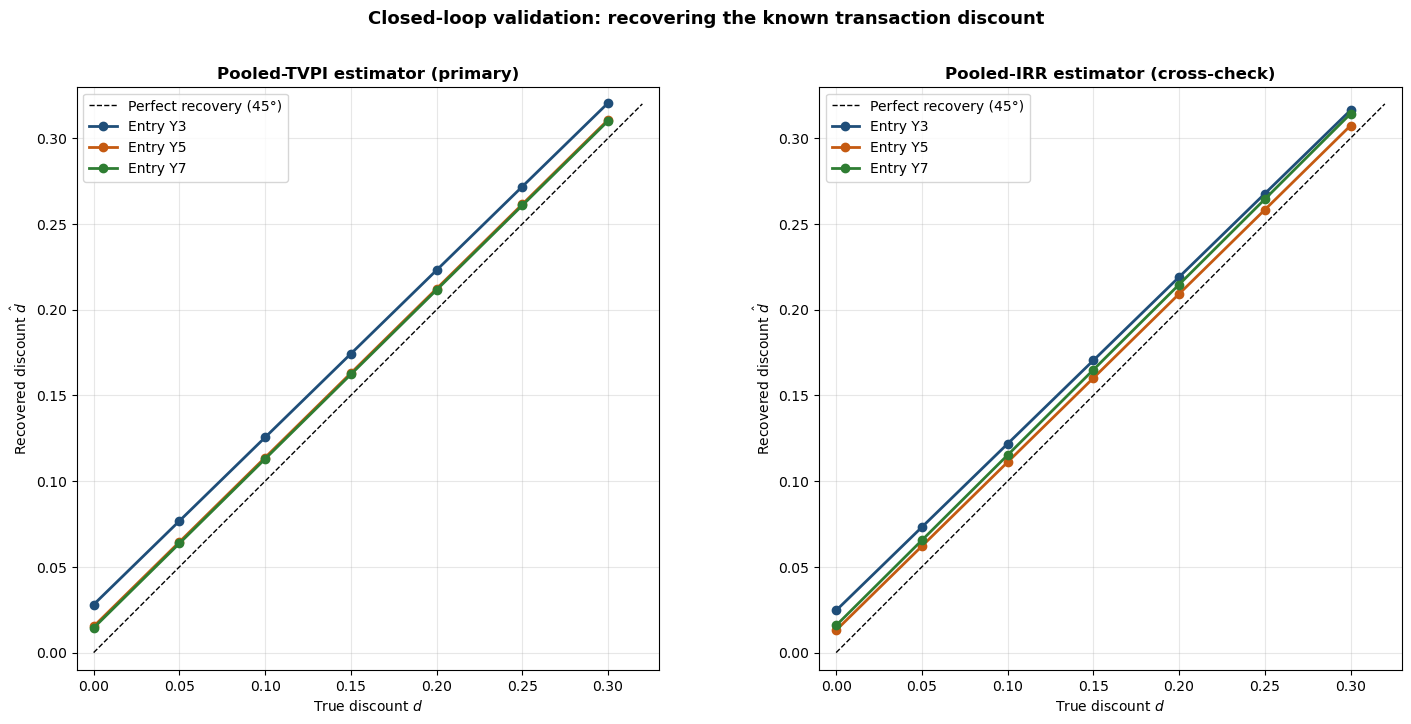

In [ ]:
# --- STEP 5: IMPLIED-DISCOUNT ESTIMATOR (closed-loop validation) ---
# Recovers the KNOWN input discount from observable performance,
# using a cross-sectional split so it is NOT an algebraic identity.
# Sample S (secondary): realized secondary performance
# Sample P (primary benchmark): counterfactual full-price entry at age tau
# Primary estimator: pooled TVPI gap.  Cross-check: pooled IRR inversion.


import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12
Q   = fund_lifetime_q


# A. INDEPENDENT SAMPLE SPLIT (mirrors real data: secondary funds
#    and the primary benchmark universe are different funds)

rng_split = np.random.default_rng(123)
perm  = rng_split.permutation(N_SIMULATIONS)
S_idx = perm[:N_SIMULATIONS // 2]   # secondary sample
P_idx = perm[N_SIMULATIONS // 2:]   # primary-benchmark sample


# B. PRECOMPUTE forward cash flows from each entry age tau

future_calls = np.zeros((N_SIMULATIONS, Q + 1))   # capital called after tau (positive)
future_dists = np.zeros((N_SIMULATIONS, Q + 1))   # distributions after tau
for tau in range(Q + 1):
    future_calls[:, tau] = -prim_calls_arr[:, tau + 1:].sum(axis=1)
    future_dists[:, tau] =  prim_dists_arr[:, tau + 1:].sum(axis=1)
terminal = true_nav_arr[:, Q]    # residual value at liquidation (~0)
net_cf   = prim_calls_arr + prim_dists_arr


# C. ESTIMATOR 1 (PRIMARY): pooled-TVPI gap

# A buyer at age tau, discount d, has cost (1-d)*NAV_tau + future calls.
# A full-price entrant (benchmark) has cost NAV_tau + future calls.
# Same future value => TVPI ratio identifies d:
#     d_hat = (1 + c) * (1 - TVPI_benchmark / TVPI_secondary),  c = future_calls / NAV_tau
def estimate_d_tvpi(tau, d_true, S_idx, P_idx):
    navS = rep_nav_arr[S_idx, tau]; navP = rep_nav_arr[P_idx, tau]
    okS = navS > eps;               okP = navP > eps
    valS = future_dists[S_idx, tau] + terminal[S_idx]
    valP = future_dists[P_idx, tau] + terminal[P_idx]
    TVPI_S = valS[okS].sum() / ((1 - d_true) * navS[okS] + future_calls[S_idx, tau][okS]).sum()
    TVPI_P = valP[okP].sum() / (navP[okP]               + future_calls[P_idx, tau][okP]).sum()
    c_bar  = future_calls[P_idx, tau][okP].sum() / navP[okP].sum()
    return (1 + c_bar) * (1 - TVPI_P / TVPI_S)


# D. ESTIMATOR 2 (CROSS-CHECK): pooled-IRR inversion

def irr_scalar(cf, lo=-0.9999, hi=10.0, n_iter=200):
    powers = np.arange(len(cf))
    npv = lambda r: (cf / (1.0 + r) ** powers).sum()
    if np.sign(npv(lo)) == np.sign(npv(hi)):
        return np.nan
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0: lo = mid
        else:            hi = mid
    return 0.5 * (lo + hi)
annualize = lambda q: (1 + q) ** 4 - 1

def pooled_irr_secondary(tau, d, idx):
    """Pooled buyer-age cash-flow stream IRR for a cohort entering at tau, discount d."""
    nav0 = rep_nav_arr[idx, tau]; ok = nav0 > eps
    stream = np.zeros(Q - tau + 1)
    stream[0] = -((1 - d) * nav0[ok]).sum()
    for k in range(1, Q - tau + 1):
        stream[k] = net_cf[idx[ok], tau + k].sum()
    return annualize(irr_scalar(stream))

def estimate_d_irr(tau, d_true, S_idx, P_idx, n_iter=60):
    """Find d_hat so the benchmark pooled IRR matches the observed secondary pooled IRR."""
    irr_S = pooled_irr_secondary(tau, d_true, S_idx)
    lo, hi = -0.5, 0.9
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if pooled_irr_secondary(tau, mid, P_idx) < irr_S: lo = mid   # IRR increasing in d_hat
        else:                                              hi = mid
    return 0.5 * (lo + hi)


# E. CLOSED-LOOP SWEEP across entry ages x true discounts

entry_ages = [(12, 'Y3'), (20, 'Y5'), (28, 'Y7')]   # slide 13: years 3, 5, 7
d_grid     = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])

results_tvpi = {}
results_irr  = {}
print("=" * 70)
print(" STEP 5: CLOSED-LOOP DISCOUNT RECOVERY")
print("=" * 70)
for tau, lab in entry_ages:
    dh_tvpi = np.array([estimate_d_tvpi(tau, d, S_idx, P_idx) for d in d_grid])
    dh_irr  = np.array([estimate_d_irr(tau, d, S_idx, P_idx)  for d in d_grid])
    results_tvpi[lab] = dh_tvpi
    results_irr[lab]  = dh_irr
    print(f"\n  Entry age {lab} (Q{tau}):")
    print(f"  {'true d':>8} {'d_hat TVPI':>11} {'d_hat IRR':>10} {'TVPI err':>9} {'IRR err':>8}")
    for d, ht, hi_ in zip(d_grid, dh_tvpi, dh_irr):
        print(f"  {d:>8.2f} {ht:>11.3f} {hi_:>10.3f} {ht-d:>+9.3f} {hi_-d:>+8.3f}")

# Mean absolute bias
all_tvpi_err = np.concatenate([results_tvpi[l] - d_grid for _, l in entry_ages])
all_irr_err  = np.concatenate([results_irr[l]  - d_grid for _, l in entry_ages])
print("\n" + "=" * 70)
print(f"  Mean bias  — TVPI estimator: {all_tvpi_err.mean():+.3f}   IRR estimator: {all_irr_err.mean():+.3f}")
print(f"  Mean |bias| — TVPI estimator: {np.abs(all_tvpi_err).mean():.3f}   IRR estimator: {np.abs(all_irr_err).mean():.3f}")
print("=" * 70)


# F. RECOVERY PLOT

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = ['#1f4e79', '#c55a11', '#2e7d32']

for ax, res, title in [(axes[0], results_tvpi, 'Pooled-TVPI estimator (primary)'),
                       (axes[1], results_irr,  'Pooled-IRR estimator (cross-check)')]:
    ax.plot([0, 0.32], [0, 0.32], 'k--', lw=1, label='Perfect recovery (45°)')
    for (tau, lab), col in zip(entry_ages, colors):
        ax.plot(d_grid, res[lab], 'o-', color=col, lw=2, ms=6, label=f'Entry {lab}')
    ax.set_xlabel('True discount $d$')
    ax.set_ylabel(r'Recovered discount $\hat d$')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3); ax.set_aspect('equal')
    ax.set_xlim(-0.01, 0.33); ax.set_ylim(-0.01, 0.33)

fig.suptitle('Closed-loop validation: recovering the known transaction discount',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()